# Importing the necessary libraries

In [2]:
# Import necessary libraries
# Core
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

In [3]:
# Load the dataset
df = pd.read_csv('D:/ShaunakKathavate Github/digital_marketing_campaign_predictor/data/raw_data.csv')
df.head()

,CustomerID,Age,Gender,Income,CampaignChannel,CampaignType,AdSpend,ClickThroughRate,ConversionRate,WebsiteVisits,PagesPerVisit,TimeOnSite,SocialShares,EmailOpens,EmailClicks,PreviousPurchases,LoyaltyPoints,AdvertisingPlatform,AdvertisingTool,Conversion
0,8000,56,Female,136912,Social Media,Awareness,6497.870068,0.043919,0.088031,0,2.399017,7.396803,19,6,9,4,688,IsConfid,ToolConfid,1
1,8001,69,Male,41760,Email,Retention,3898.668606,0.155725,0.182725,42,2.917138,5.352549,5,2,7,2,3459,IsConfid,ToolConfid,1
2,8002,46,Female,88456,PPC,Awareness,1546.429596,0.277490,0.076423,2,8.223619,13.794901,0,11,2,8,2337,IsConfid,ToolConfid,1
3,8003,32,Female,44085,PPC,Conversion,539.525936,0.137611,0.088004,47,4.540939,14.688363,89,2,2,0,2463,IsConfid,ToolConfid,1
4,8004,60,Female,83964,PPC,Conversion,1678.043573,0.252851,0.109940,0,2.046847,13.993370,6,6,6,8,4345,IsConfid,ToolConfid,1


In [4]:
# Basic data inspection
print("Shape of dataset:", df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

print("\nDataset Info:")
print(df.info())

Shape of dataset: (8000, 20)

Column Names:
Index(['CustomerID', 'Age', 'Gender', 'Income', 'CampaignChannel',
       'CampaignType', 'AdSpend', 'ClickThroughRate', 'ConversionRate',
       'WebsiteVisits', 'PagesPerVisit', 'TimeOnSite', 'SocialShares',
       'EmailOpens', 'EmailClicks', 'PreviousPurchases', 'LoyaltyPoints',
       'AdvertisingPlatform', 'AdvertisingTool', 'Conversion'],
      dtype='object')

Data Types:
CustomerID               int64
Age                      int64
Gender                  object
Income                   int64
CampaignChannel         object
CampaignType            object
AdSpend                float64
ClickThroughRate       float64
ConversionRate         float64
WebsiteVisits            int64
PagesPerVisit          float64
TimeOnSite             float64
SocialShares             int64
EmailOpens               int64
EmailClicks              int64
PreviousPurchases        int64
LoyaltyPoints            int64
AdvertisingPlatform     object
AdvertisingTool

In [5]:
# Statistical Summary
# Numerical summary
df.describe()

,CustomerID,Age,Income,AdSpend,ClickThroughRate,ConversionRate,WebsiteVisits,PagesPerVisit,TimeOnSite,SocialShares,EmailOpens,EmailClicks,PreviousPurchases,LoyaltyPoints,Conversion
count,8000.00000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000
mean,11999.50000,43.625500,84664.196750,5000.944830,0.154829,0.104389,24.751625,5.549299,7.727718,49.799750,9.476875,4.467375,4.485500,2490.268500,0.876500
std,2309.54541,14.902785,37580.387945,2838.038153,0.084007,0.054878,14.312269,2.607358,4.228218,28.901165,5.711111,2.856564,2.888093,1429.527162,0.329031
min,8000.00000,18.000000,20014.000000,100.054813,0.010005,0.010018,0.000000,1.000428,0.501669,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,9999.75000,31.000000,51744.500000,2523.221165,0.082635,0.056410,13.000000,3.302479,4.068340,25.000000,5.000000,2.000000,2.000000,1254.750000,1.000000
50%,11999.50000,43.000000,84926.500000,5013.440044,0.154505,0.104046,25.000000,5.534257,7.682956,50.000000,9.000000,4.000000,4.000000,2497.000000,1.000000
75%,13999.25000,56.000000,116815.750000,7407.989369,0.228207,0.152077,37.000000,7.835756,11.481468,75.000000,14.000000,7.000000,7.000000,3702.250000,1.000000
max,15999.00000,69.000000,149986.000000,9997.914781,0.299968,0.199995,49.000000,9.999055,14.995311,99.000000,19.000000,9.000000,9.000000,4999.000000,1.000000


In [6]:
# Categorical summary
df.describe(include='object')

,Gender,CampaignChannel,CampaignType,AdvertisingPlatform,AdvertisingTool
count,8000,8000,8000,8000,8000
unique,2,5,4,1,1
top,Female,Referral,Conversion,IsConfid,ToolConfid
freq,4839,1719,2077,8000,8000


In [7]:
# Check missing values
missing_values = df.isnull().sum()

missing_percent = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    "Missing Count": missing_values,
    "Missing %": missing_percent
})

print(missing_df[missing_df["Missing Count"] > 0])

Empty DataFrame
Columns: [Missing Count, Missing %]
Index: []


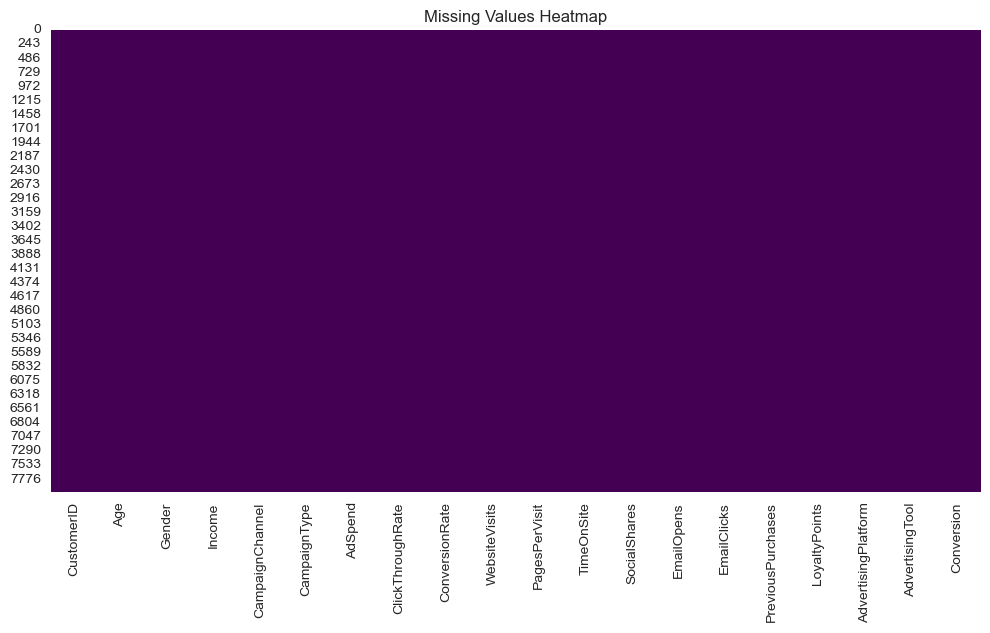

In [8]:
# Visualize missing values
plt.figure(figsize=(12,6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title("Missing Values Heatmap")
plt.show()

In [9]:
# Check for duplicates
duplicates = df.duplicated().sum()

print("Total Duplicate Rows:", duplicates)

Total Duplicate Rows: 0


Conversion
1    7012
0     988
Name: count, dtype: int64


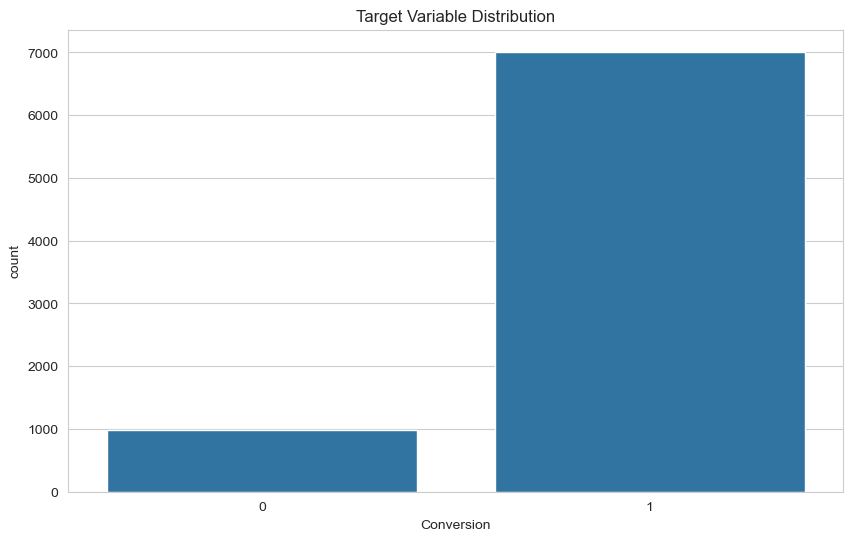

In [10]:
# Target variable analysis
print(df['Conversion'].value_counts())

sns.countplot(x='Conversion', data=df)
plt.title("Target Variable Distribution")
plt.show()

In [11]:
# Class imbalance check
conversion_rate = df['Conversion'].value_counts(normalize=True) * 100
print(conversion_rate)

Conversion
1    87.65
0    12.35
Name: proportion, dtype: float64


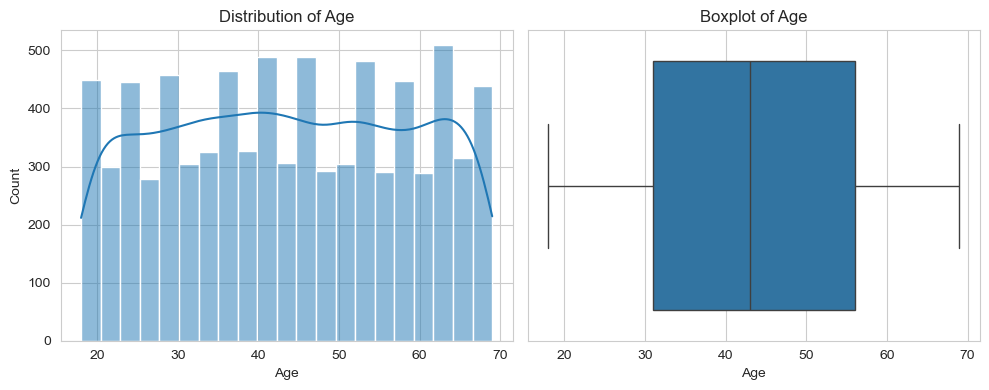

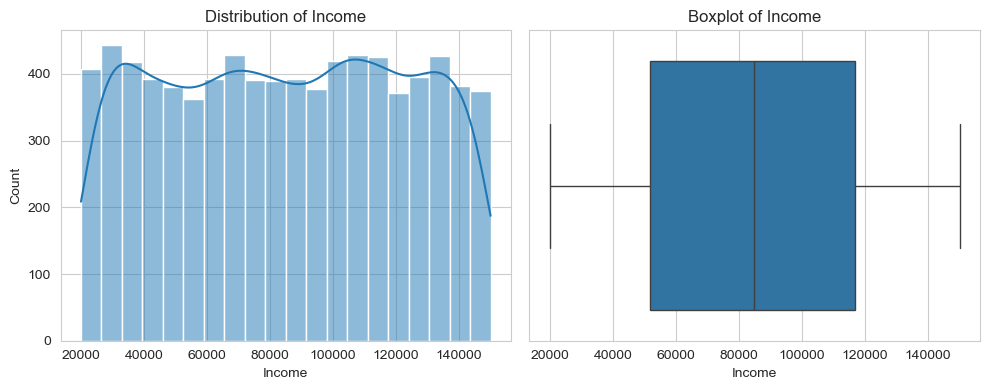

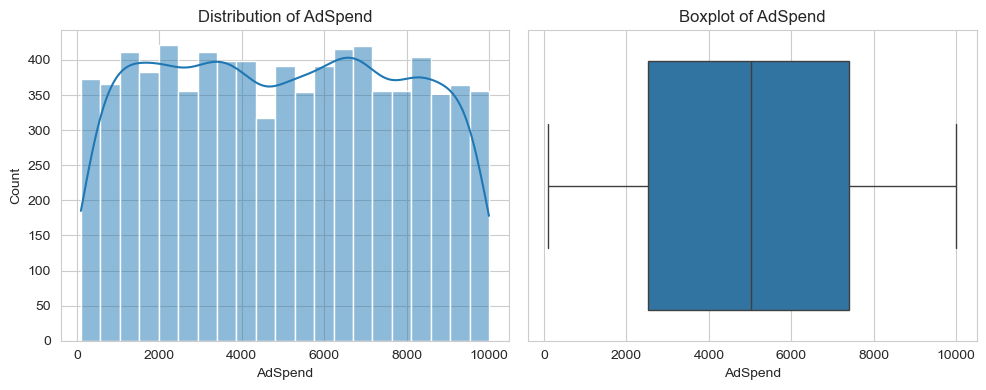

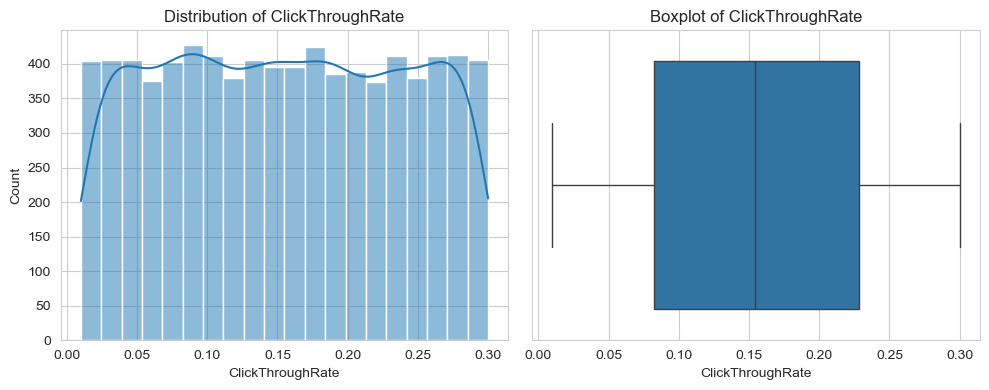

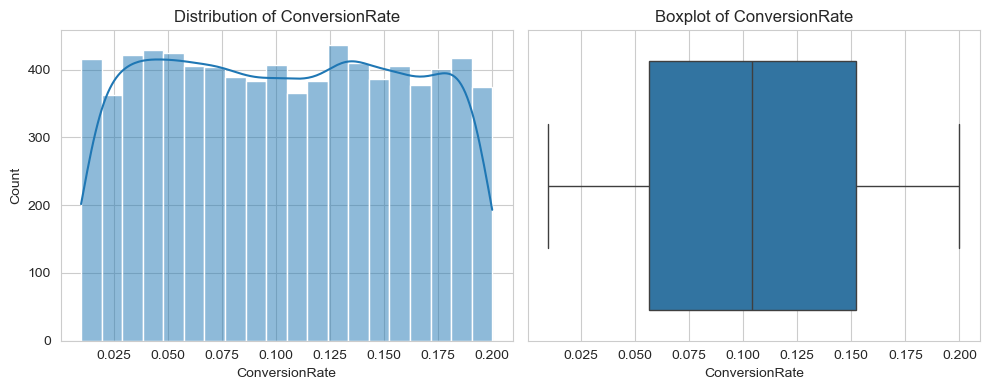

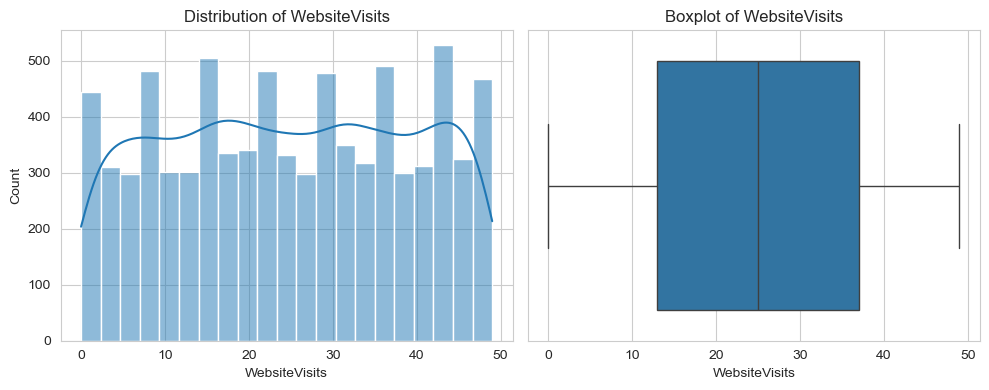

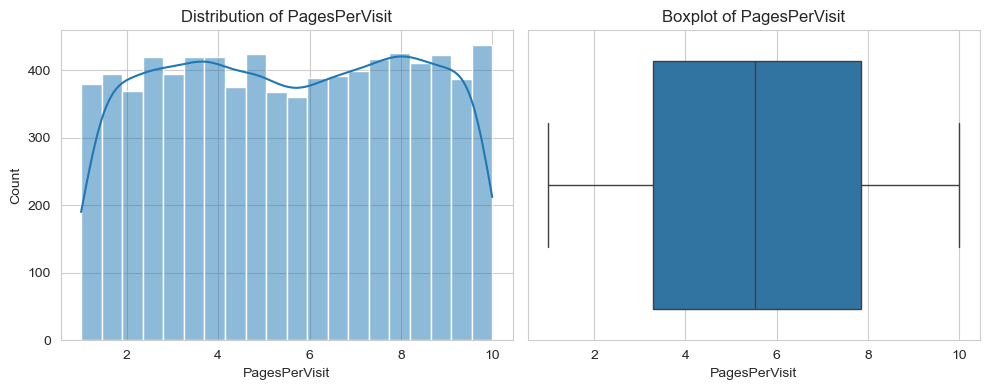

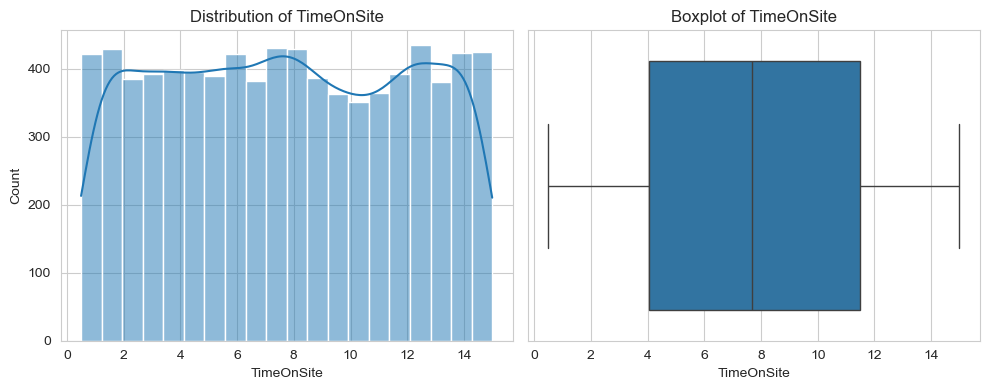

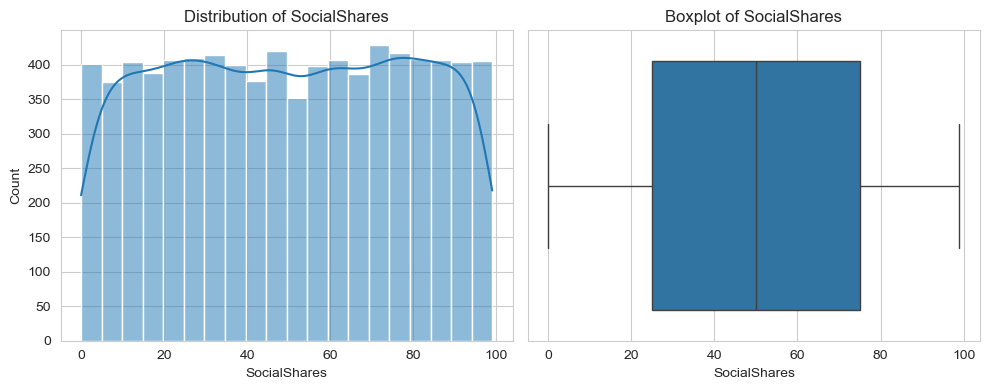

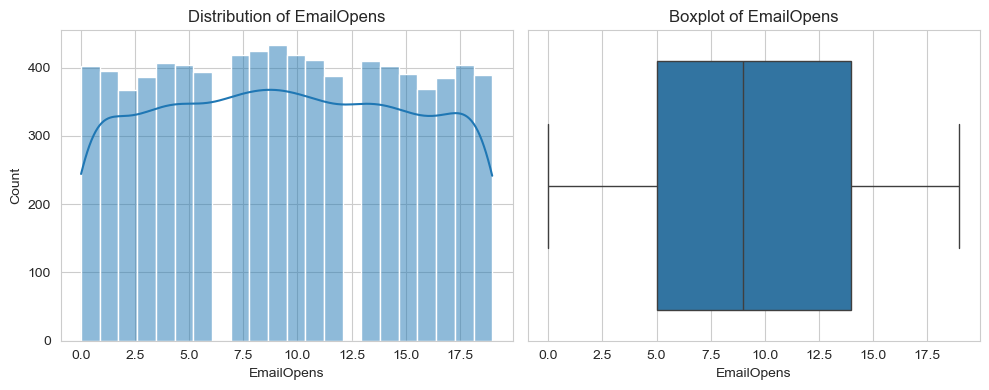

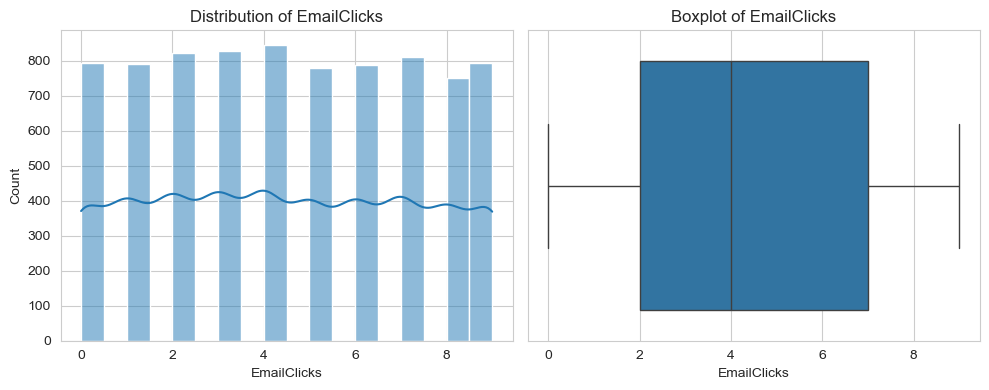

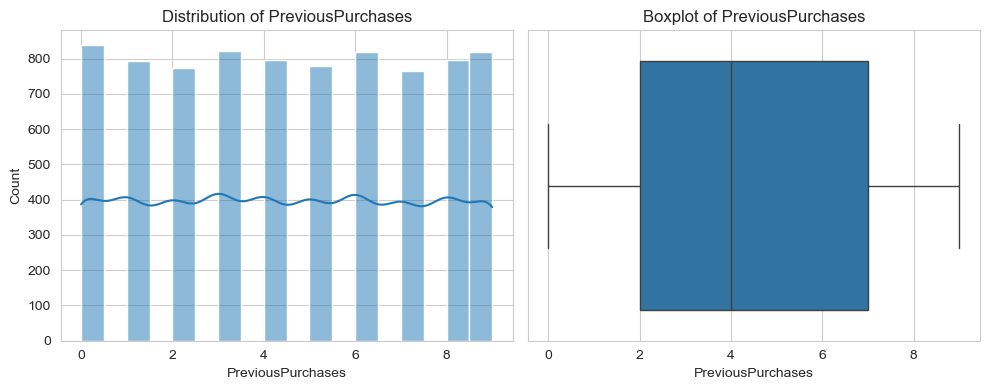

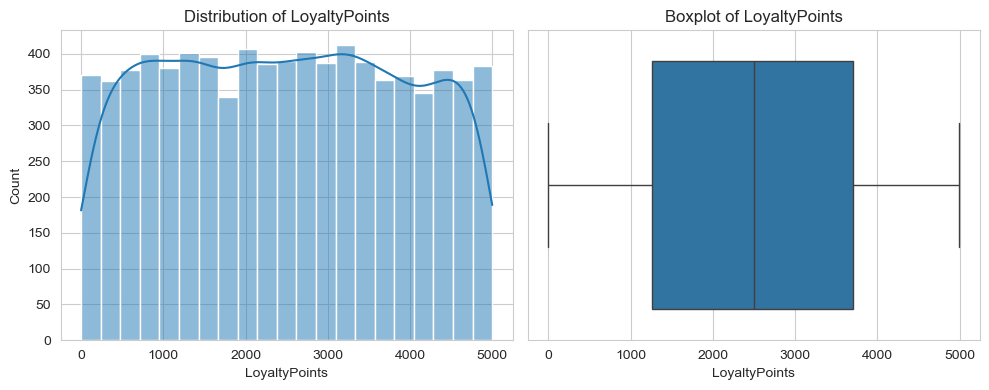

In [12]:
# Univariate analysis of numerical features
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Remove target and ID if needed
numerical_cols.remove('Conversion')
numerical_cols.remove('CustomerID')

for col in numerical_cols:
    plt.figure(figsize=(10,4))

    plt.subplot(1,2,1)
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')

    plt.subplot(1,2,2)
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')

    plt.tight_layout()
    plt.show()

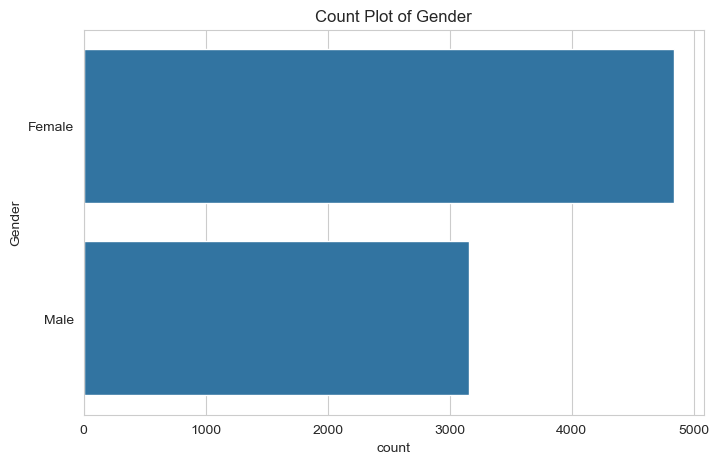

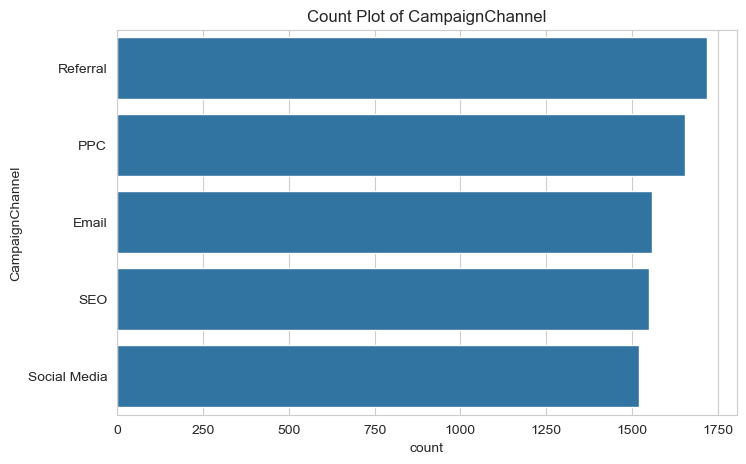

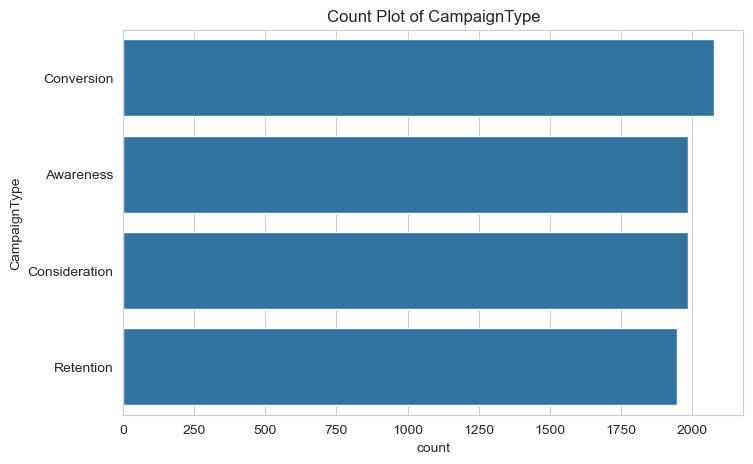

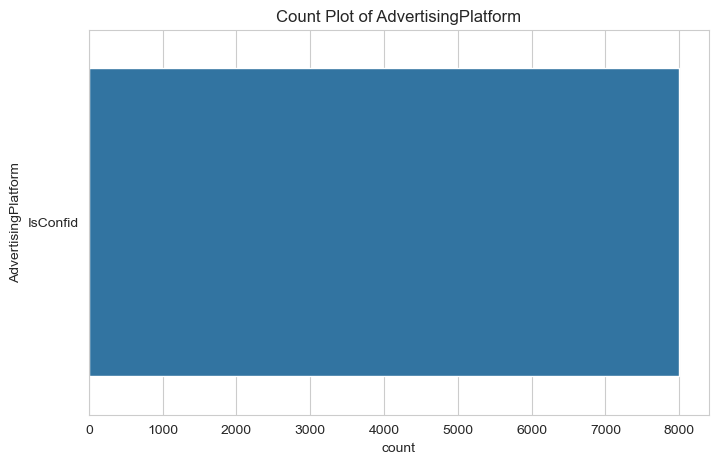

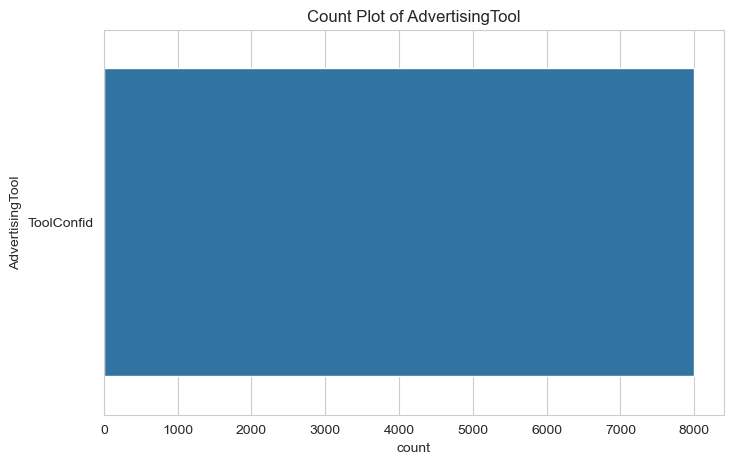

In [13]:
# Univariate analysis of categorical features
categorical_cols = df.select_dtypes(include='object').columns.tolist()

for col in categorical_cols:
    plt.figure(figsize=(8,5))
    sns.countplot(y=col, data=df, order=df[col].value_counts().index)
    plt.title(f"Count Plot of {col}")
    plt.show()

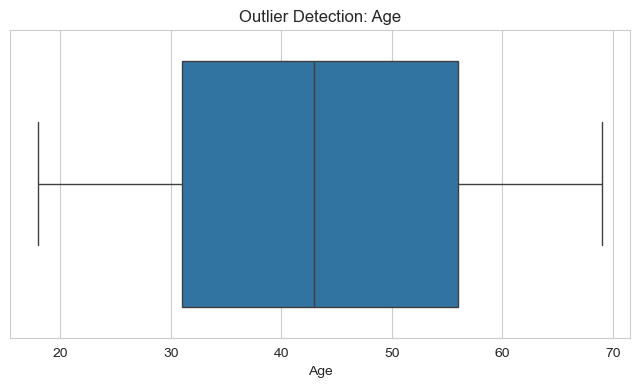

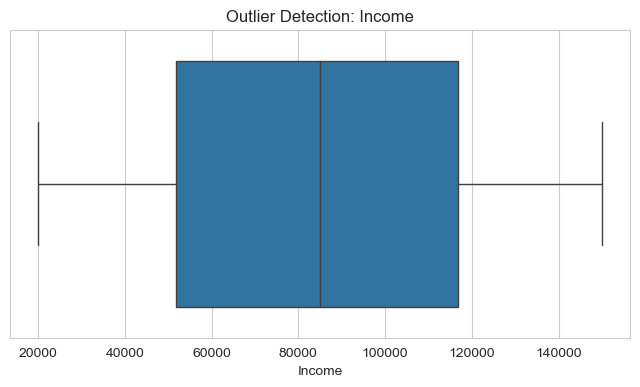

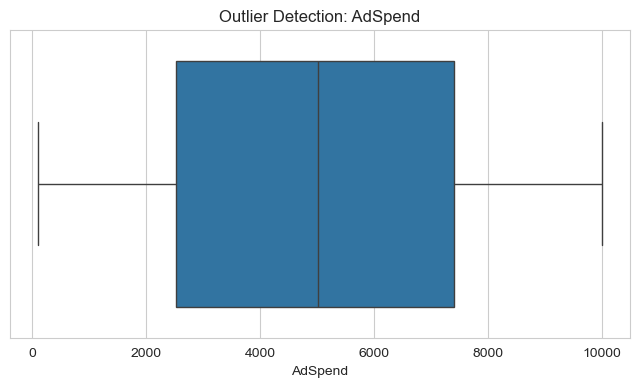

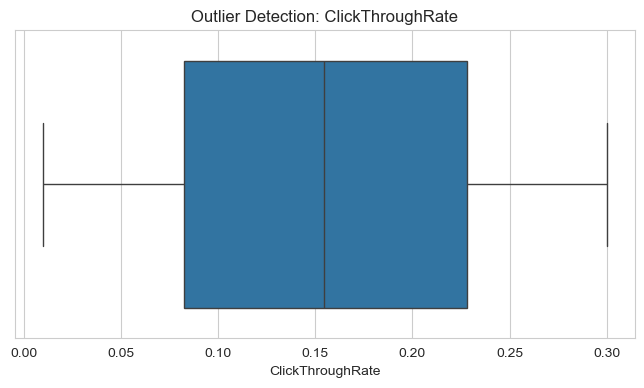

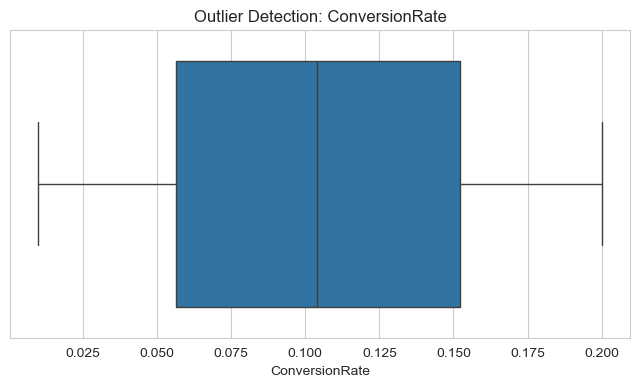

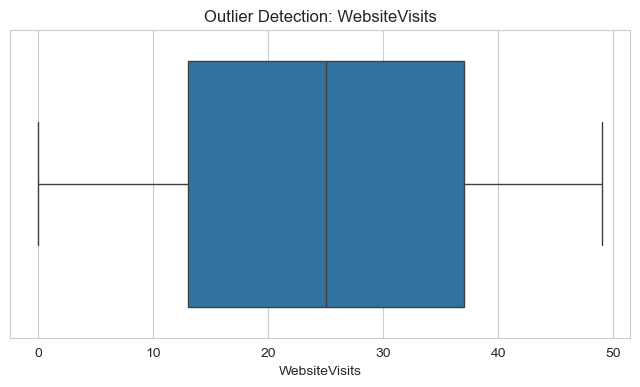

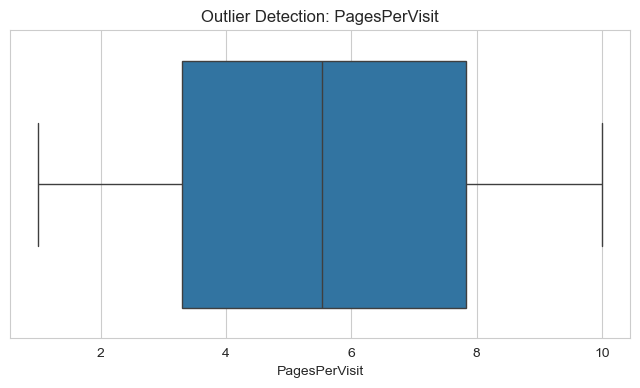

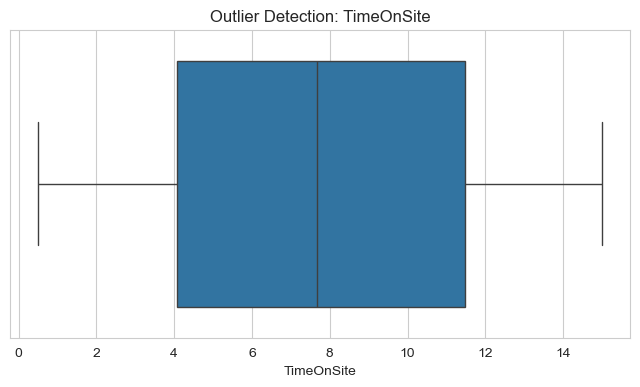

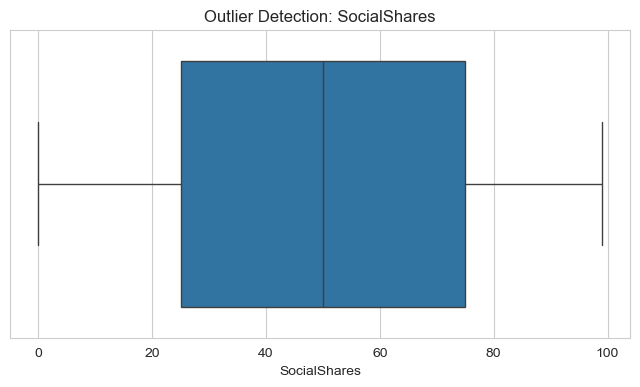

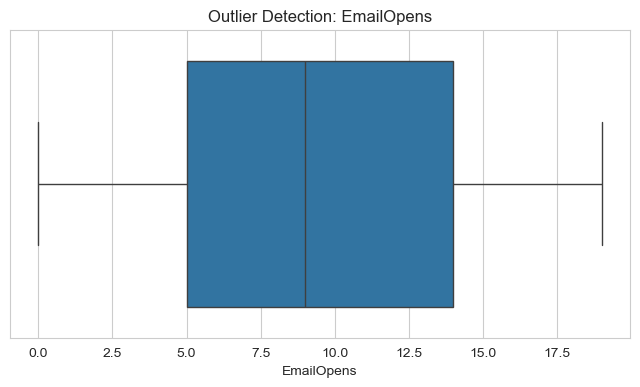

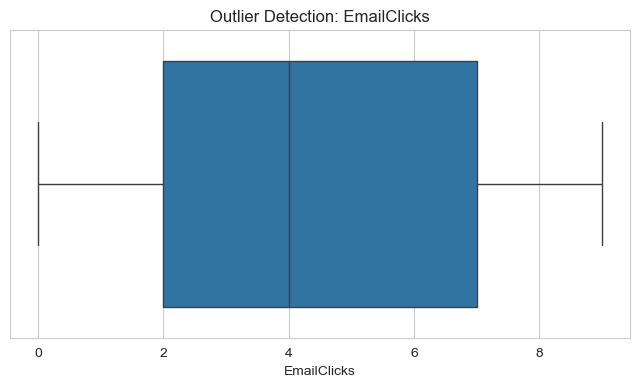

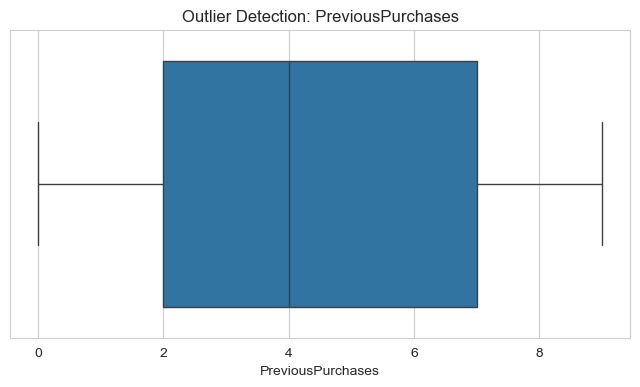

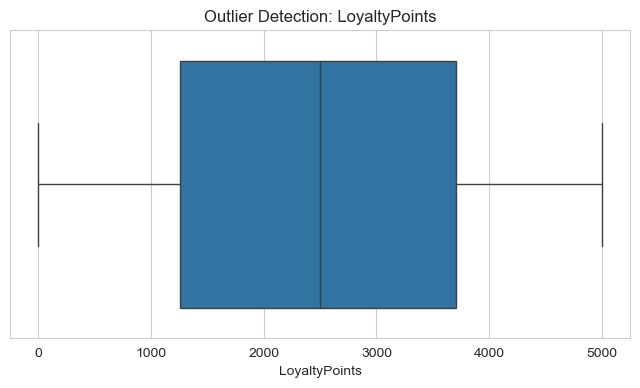

In [14]:
# Outlier detection using boxplots
for col in numerical_cols:
    plt.figure(figsize=(8,4))
    sns.boxplot(x=df[col])
    plt.title(f"Outlier Detection: {col}")
    plt.show()

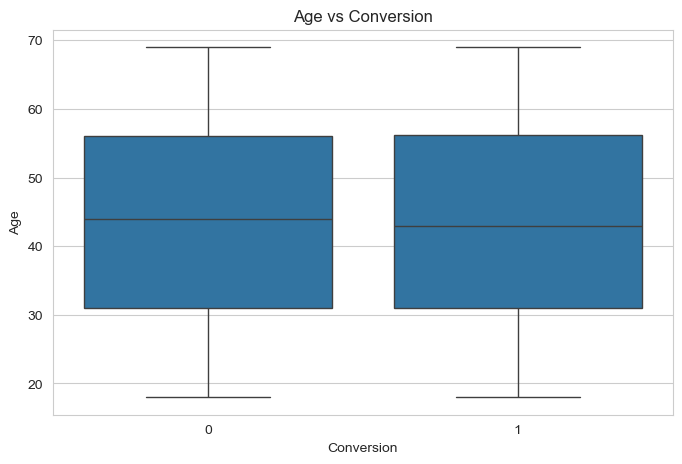

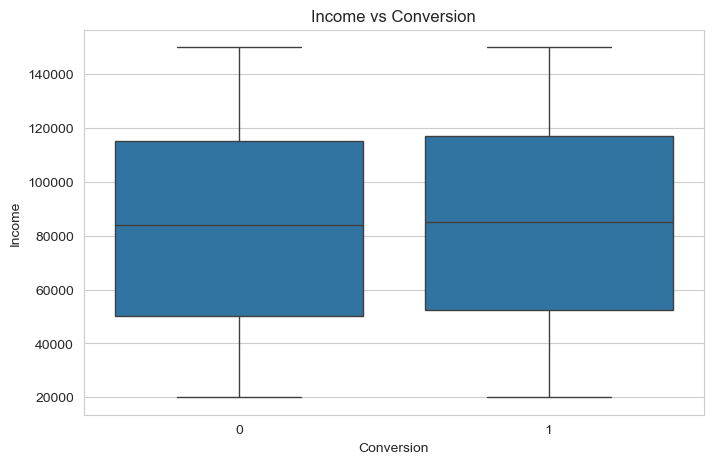

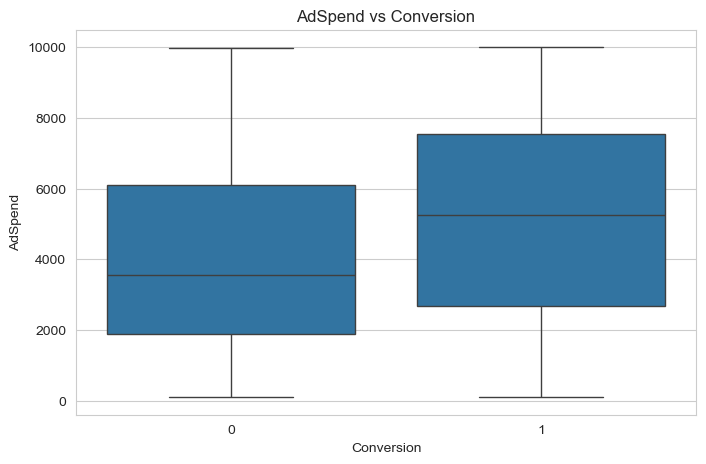

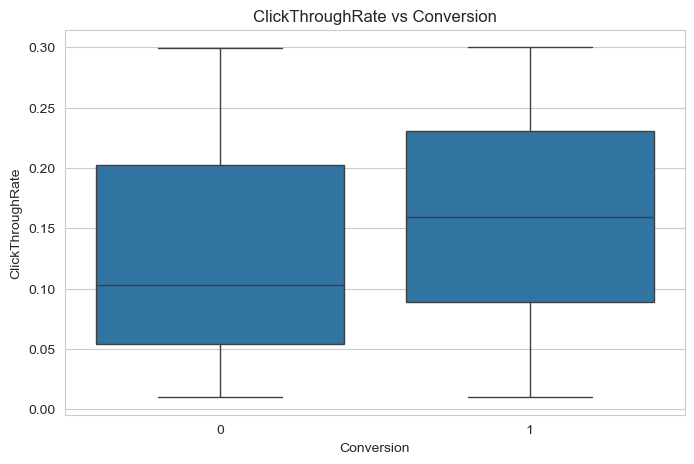

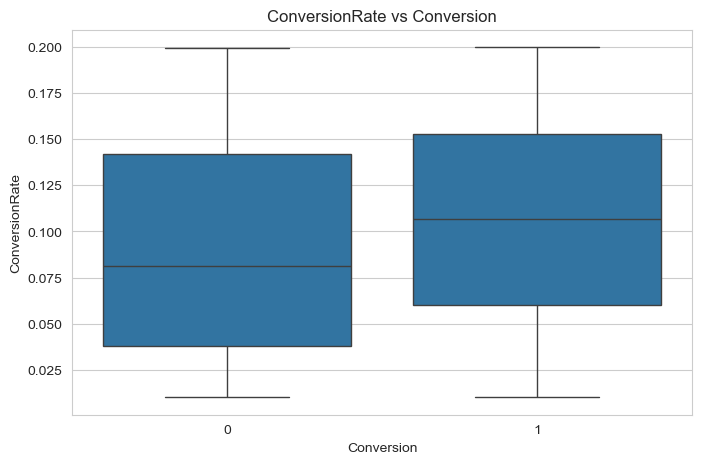

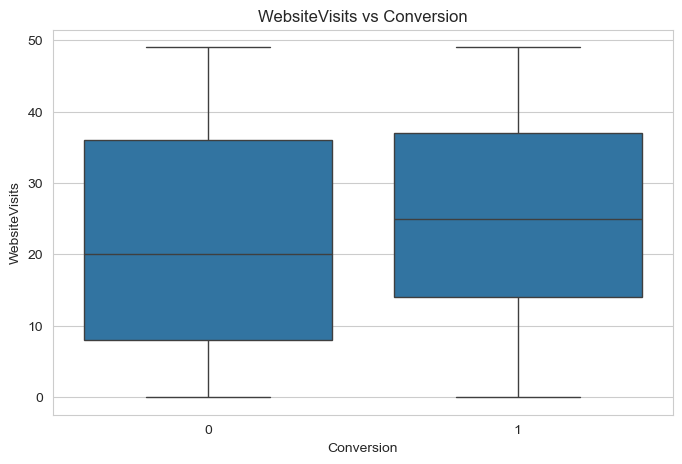

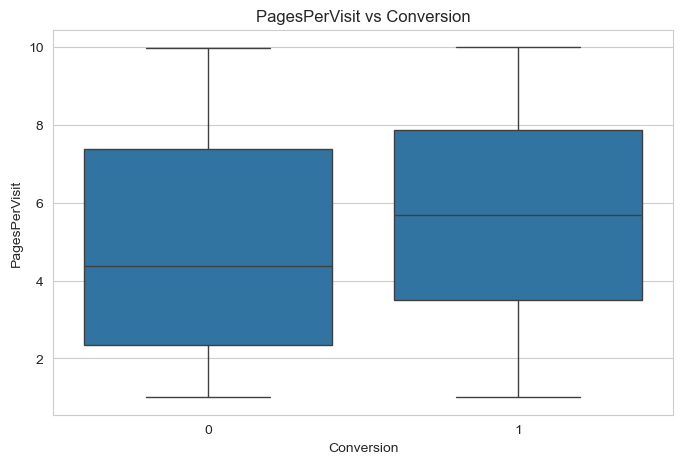

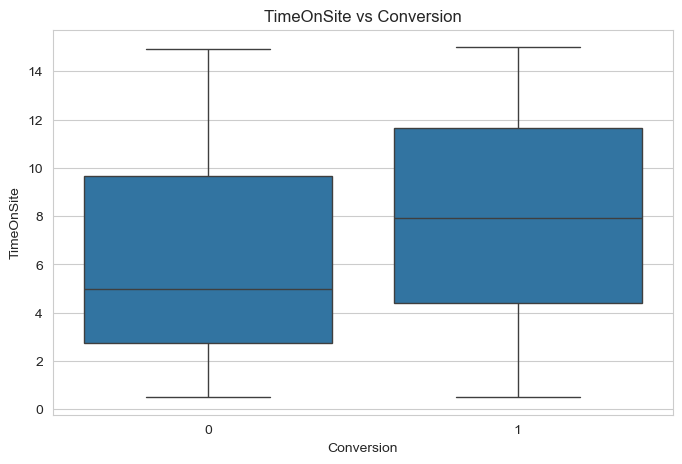

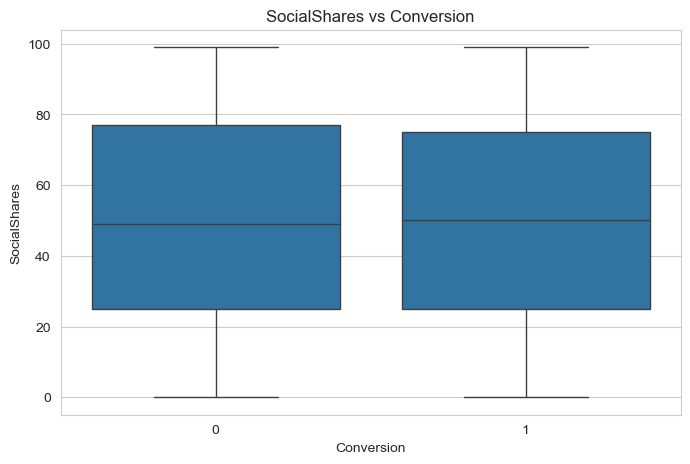

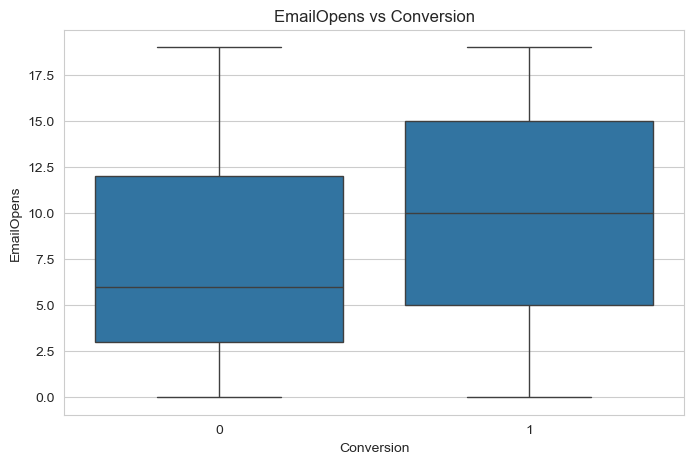

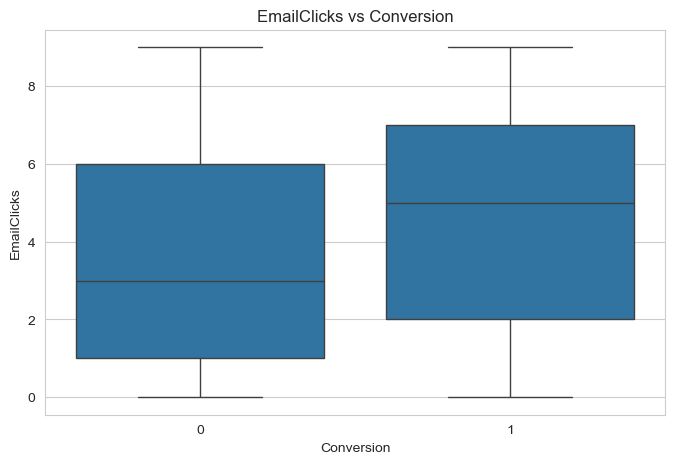

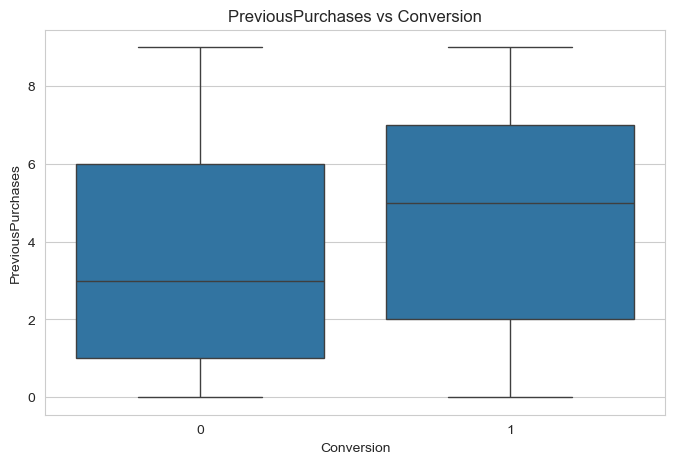

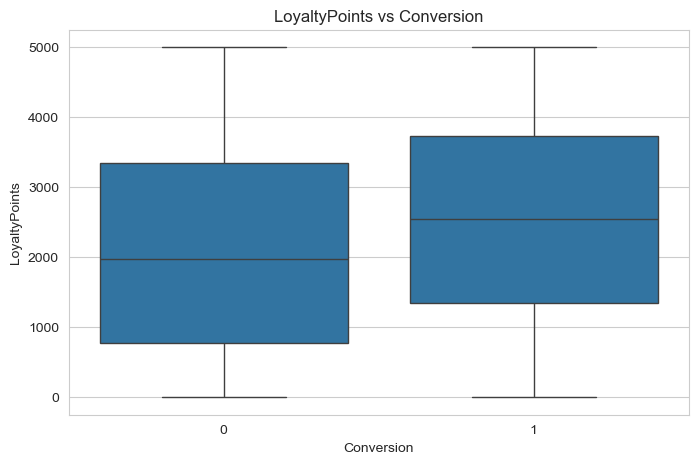

In [15]:
# Bivariate analysis: Numerical features vs Target
for col in numerical_cols:
    plt.figure(figsize=(8,5))
    sns.boxplot(x='Conversion', y=col, data=df)
    plt.title(f"{col} vs Conversion")
    plt.show()

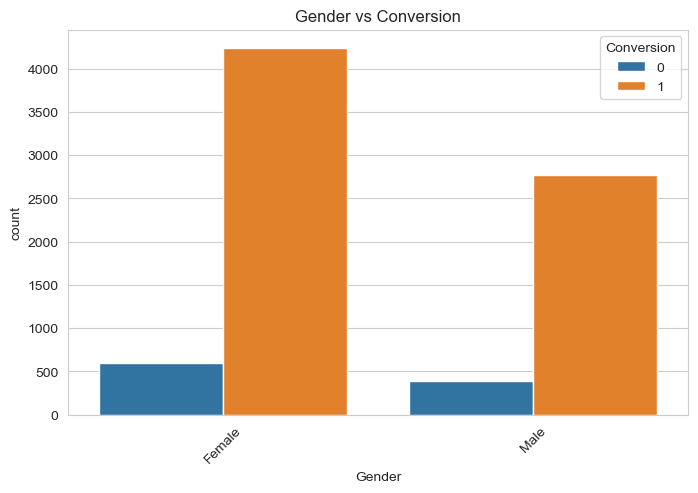

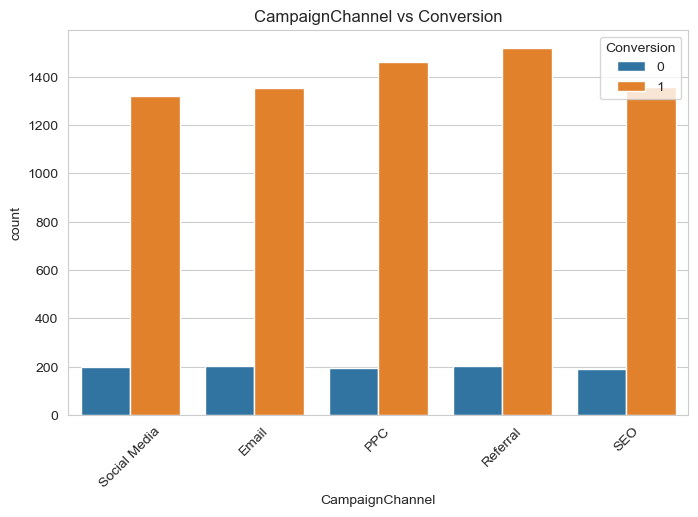

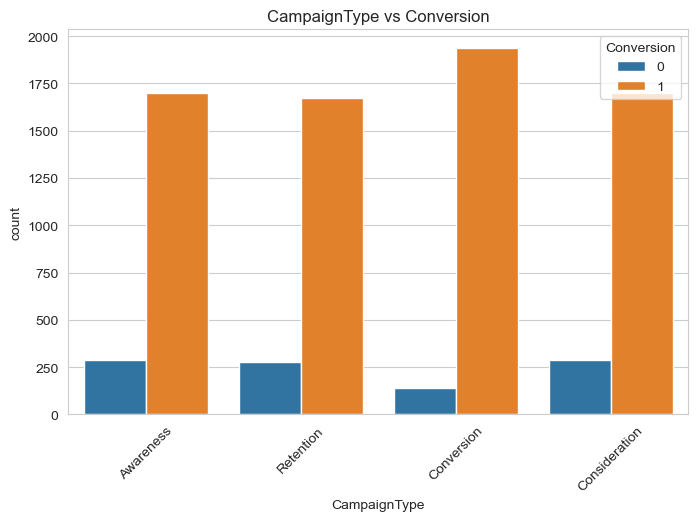

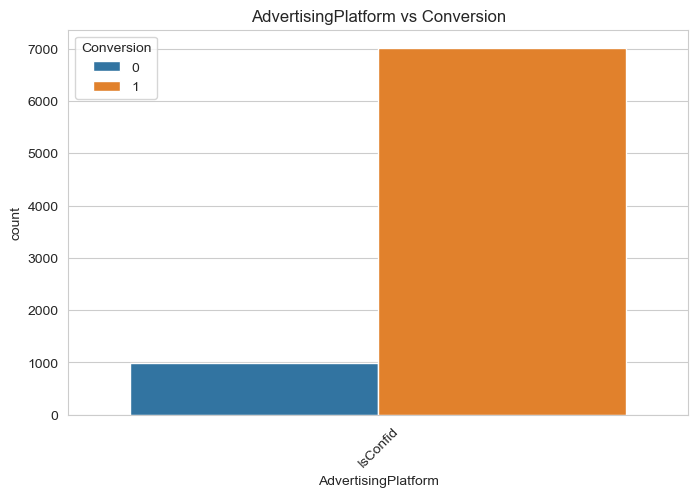

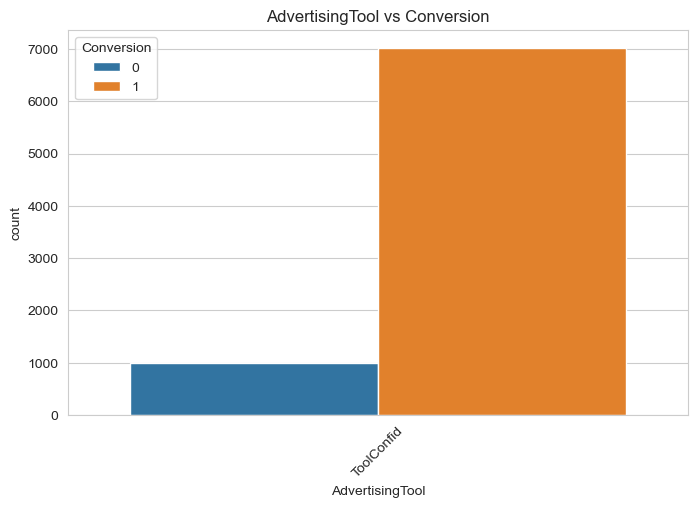

In [16]:
# Bivariate analysis: Categorical features vs Target
for col in categorical_cols:
    plt.figure(figsize=(8,5))
    sns.countplot(x=col, hue='Conversion', data=df)
    plt.title(f"{col} vs Conversion")
    plt.xticks(rotation=45)
    plt.show()

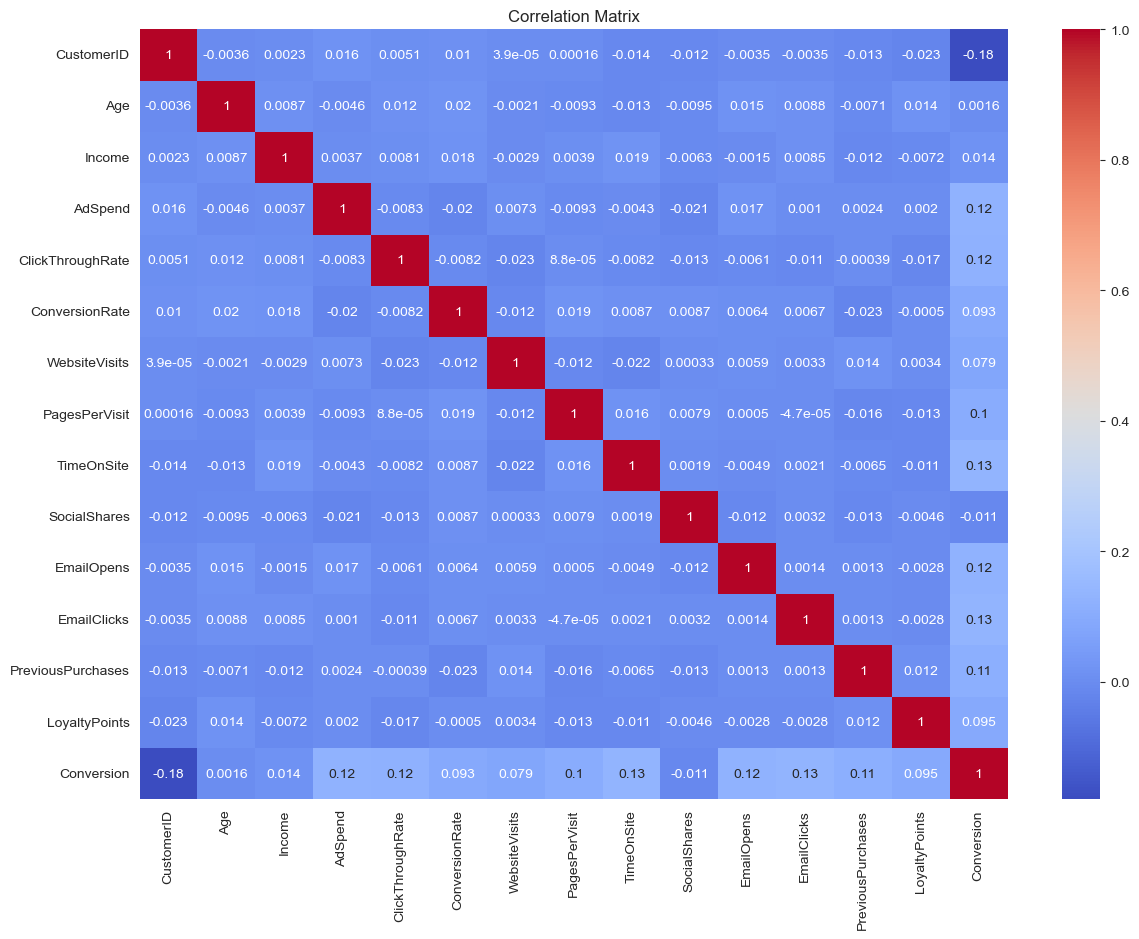

In [17]:
# Correlation analysis
corr_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(14,10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [18]:
# Identify highly correlated features (threshold > 0.80)
high_corr = corr_matrix[(corr_matrix > 0.80) & (corr_matrix < 1.0)]

print(high_corr)

                   CustomerID  Age  Income  AdSpend  ClickThroughRate  \
CustomerID                NaN  NaN     NaN      NaN               NaN   
Age                       NaN  NaN     NaN      NaN               NaN   
Income                    NaN  NaN     NaN      NaN               NaN   
AdSpend                   NaN  NaN     NaN      NaN               NaN   
ClickThroughRate          NaN  NaN     NaN      NaN               NaN   
ConversionRate            NaN  NaN     NaN      NaN               NaN   
WebsiteVisits             NaN  NaN     NaN      NaN               NaN   
PagesPerVisit             NaN  NaN     NaN      NaN               NaN   
TimeOnSite                NaN  NaN     NaN      NaN               NaN   
SocialShares              NaN  NaN     NaN      NaN               NaN   
EmailOpens                NaN  NaN     NaN      NaN               NaN   
EmailClicks               NaN  NaN     NaN      NaN               NaN   
PreviousPurchases         NaN  NaN     NaN      NaN

In [19]:
# Which campaign channel gives highest conversions?

channel_conversion = pd.crosstab(
    df['CampaignChannel'],
    df['Conversion'],
    normalize='index'
) * 100

print(channel_conversion)

Conversion               0          1
CampaignChannel                      
Email            12.973667  87.026333
PPC              11.722054  88.277946
Referral         11.692845  88.307155
SEO              12.322581  87.677419
Social Media     13.166557  86.833443


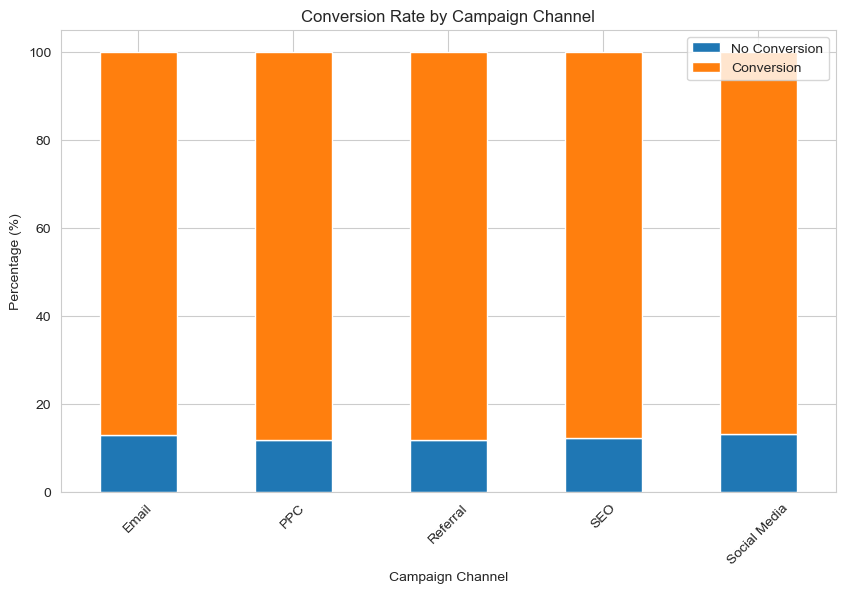

In [20]:
# Visualize conversion rates by campaign channel
# Rename columns for clarity
channel_conversion.columns = ['No Conversion', 'Conversion']


channel_conversion.plot(
    kind='bar',
    stacked=True,
    figsize=(10,6)
)

plt.title("Conversion Rate by Campaign Channel")
plt.ylabel("Percentage (%)")
plt.xlabel("Campaign Channel")
plt.legend(loc='upper right')
plt.xticks(rotation=45)
plt.show()

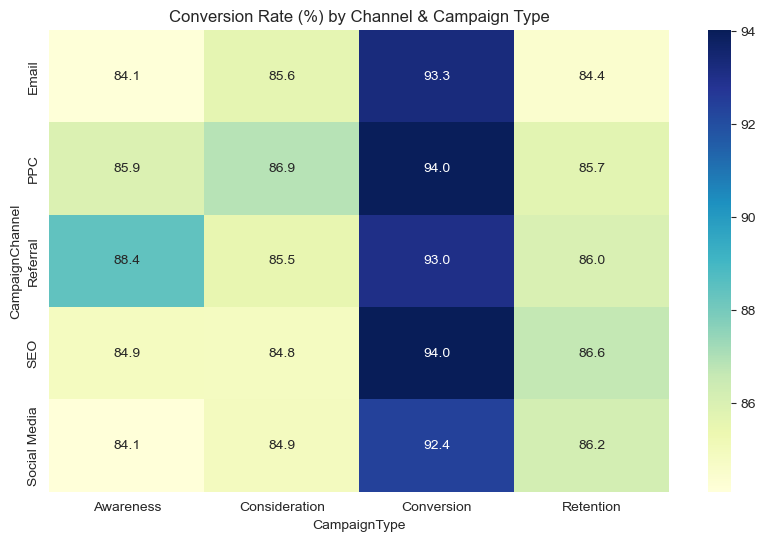

In [21]:
# Which campaign type gives highest conversions?
pivot_table = pd.pivot_table(
    df,
    values='Conversion',
    index='CampaignChannel',
    columns='CampaignType',
    aggfunc='mean'
) * 100

plt.figure(figsize=(10,6))
sns.heatmap(pivot_table, annot=True, fmt=".1f", cmap="YlGnBu")

plt.title("Conversion Rate (%) by Channel & Campaign Type")
plt.show()

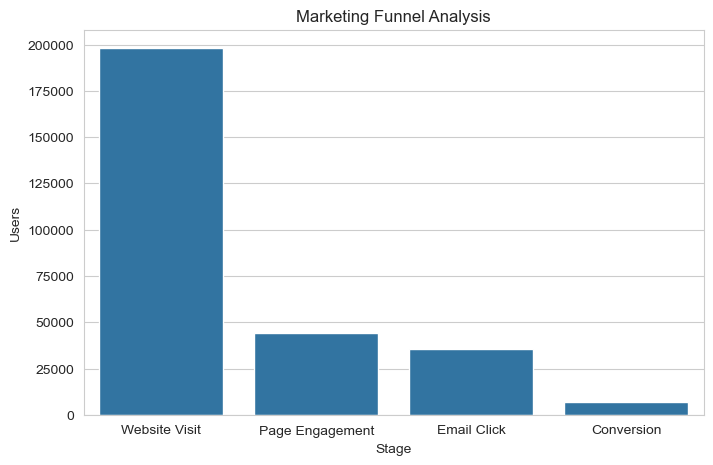

In [22]:
# Analyze the marketing funnel: Website Visits → Page Engagement → Email Clicks → Conversion
funnel_data = {
    "Stage": ["Website Visit", "Page Engagement", "Email Click", "Conversion"],
    "Users": [
        df['WebsiteVisits'].sum(),
        df['PagesPerVisit'].sum(),
        df['EmailClicks'].sum(),
        df['Conversion'].sum()
    ]
}

funnel_df = pd.DataFrame(funnel_data)

plt.figure(figsize=(8,5))
sns.barplot(x="Stage", y="Users", data=funnel_df)

plt.title("Marketing Funnel Analysis")
plt.show()

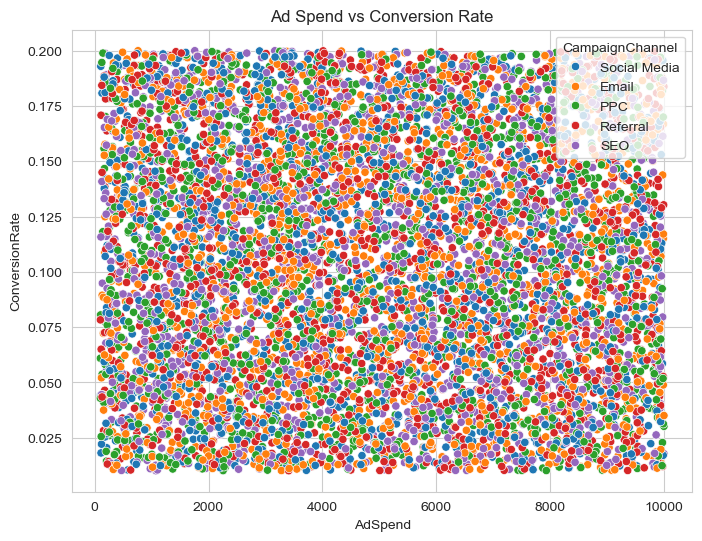

In [23]:
# Explore the relationship between Ad Spend and Conversion Rate
plt.figure(figsize=(8,6))
sns.scatterplot(
    x='AdSpend',
    y='ConversionRate',
    hue='CampaignChannel',
    data=df
)

plt.title("Ad Spend vs Conversion Rate")
plt.show()

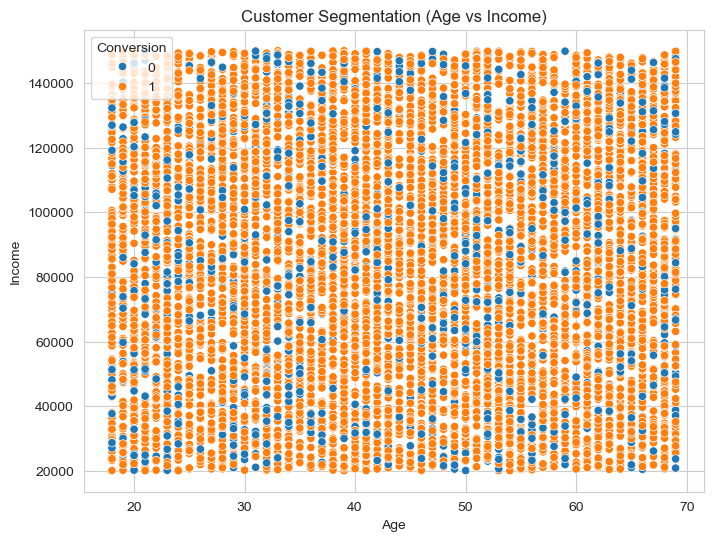

In [24]:
# Explore the relationship between Age and Income, colored by Conversion
plt.figure(figsize=(8,6))
sns.scatterplot(
    x='Age',
    y='Income',
    hue='Conversion',
    data=df
)

plt.title("Customer Segmentation (Age vs Income)")
plt.show()

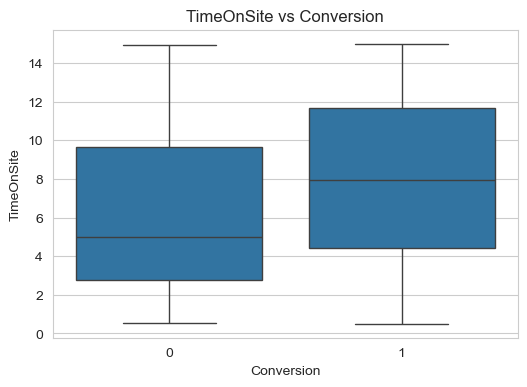

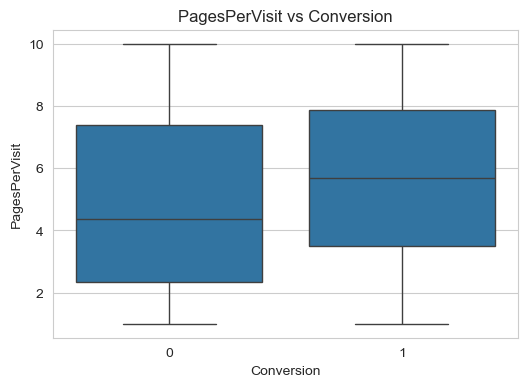

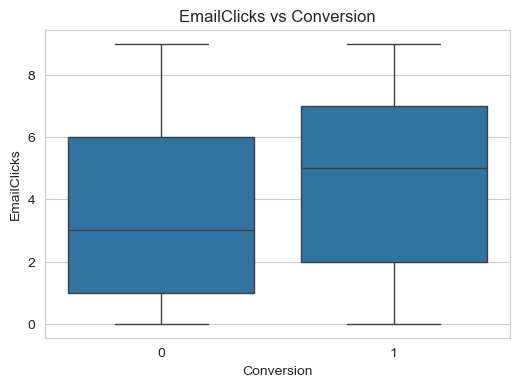

In [25]:
# Explore the relationship between Time on Site, Pages per Visit, Email Clicks and Conversion
engagement_cols = ['TimeOnSite', 'PagesPerVisit', 'EmailClicks']

for col in engagement_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x='Conversion', y=col, data=df)
    plt.title(f"{col} vs Conversion")
    plt.show()

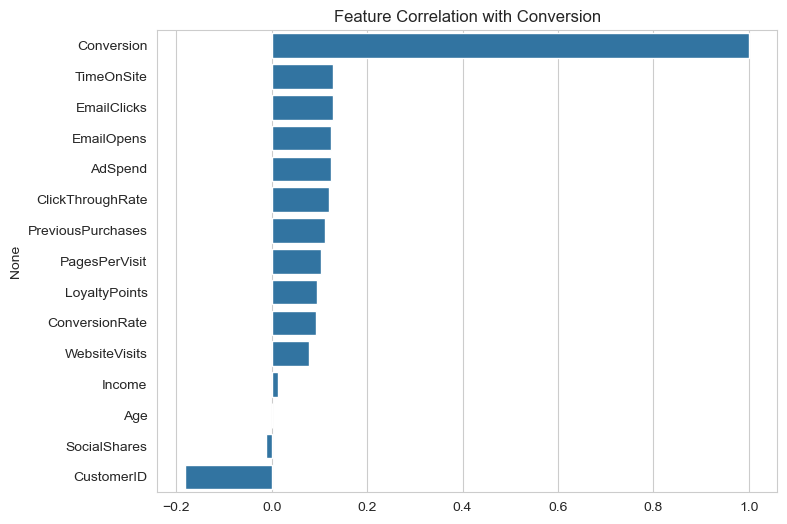

In [26]:
# Correlation of features with target variable
corr = df.corr(numeric_only=True)['Conversion'].sort_values(ascending=False)

plt.figure(figsize=(8,6))
sns.barplot(x=corr.values, y=corr.index)

plt.title("Feature Correlation with Conversion")
plt.show()

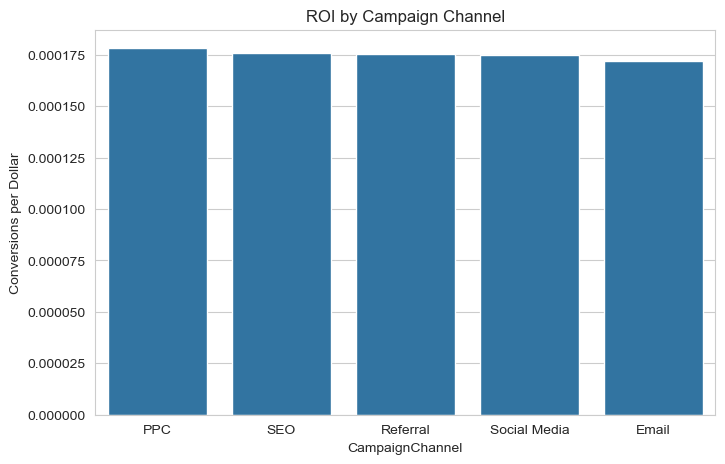

In [27]:
# Calculate ROI (Return on Investment) for each campaign channel
roi = df.groupby('CampaignChannel').apply(
    lambda x: (x['Conversion'].sum() / x['AdSpend'].sum())
)

roi = roi.sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=roi.index, y=roi.values)

plt.title("ROI by Campaign Channel")
plt.ylabel("Conversions per Dollar")
plt.show()

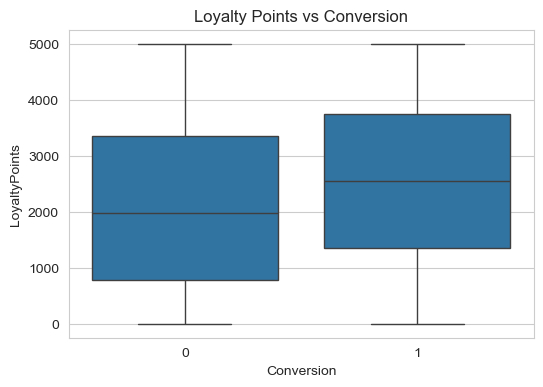

In [28]:
# Explore the relationship between Loyalty Points and Conversion
plt.figure(figsize=(6,4))
sns.boxplot(x='Conversion', y='LoyaltyPoints', data=df)

plt.title("Loyalty Points vs Conversion")
plt.show()

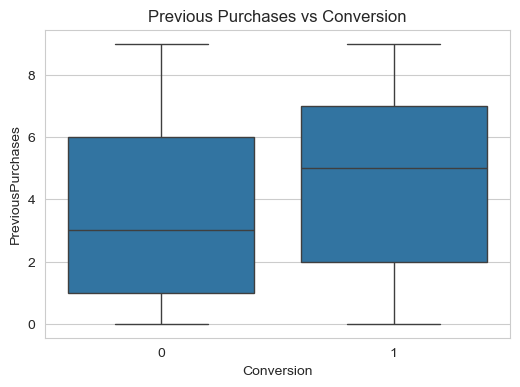

In [29]:
# Explore the relationship between Previous Purchases and Conversion
plt.figure(figsize=(6,4))
sns.boxplot(x='Conversion', y='PreviousPurchases', data=df)

plt.title("Previous Purchases vs Conversion")
plt.show()

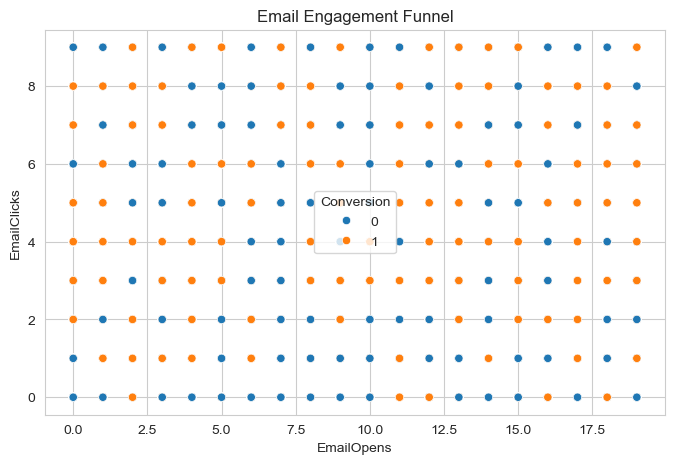

In [30]:
# Explore the relationship between Email Opens, Email Clicks and Conversion
plt.figure(figsize=(8,5))
sns.scatterplot(
    x='EmailOpens',
    y='EmailClicks',
    hue='Conversion',
    data=df
)

plt.title("Email Engagement Funnel")
plt.show()

In [ ]:
# Explore the relationship between Previous Purchases and Conversion
plt.figure(figsize=(6,4))
sns.boxp